In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import torch

from trajectory_based_utils import get_fds, fd_vs_snaps, overfit_vs_snaps
from generalization_gap_utils import gen_gap_vs_model_error, plot_layout, sigma_ids, gg_vs_snaps

plt.style.use('default')

%load_ext autoreload
%autoreload 2

data_folder = '/home/shared/generative_models/diffusion_overfit/data'
figs_folder = '/home/tikai103/diffusion_overfit/plots'
save_figs = False

# Contents

### This notebook generates all plots for our trajectory-based metrics.
1. [Generalization gap vs training time](#1.-Generalization-gap-vs-training-time)
2. [Early stopping vs sigma](#2.-Early-stopping-vs-sigma)
3. [Generalization gap for diffusion guidance](#3.-Generalization-gap-for-diffusion-guidance)

## 1. Generalization gap vs training time

### ImageNet-64/512

Model: xs-uncond, stopped at: -1
Model: xs       , stopped at: -1
Model: s        , stopped at: -1
Model: m        , stopped at: -1
Model: l        , stopped at: -1
Model: xl       , stopped at: -1


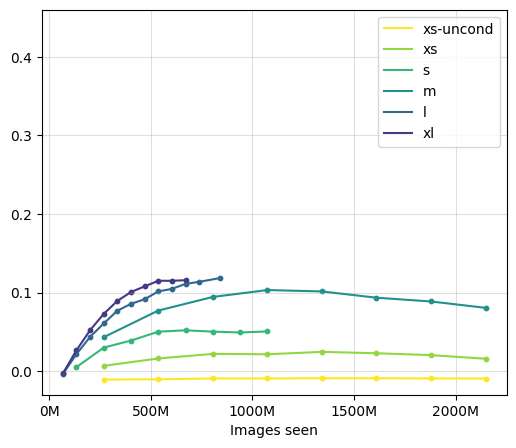

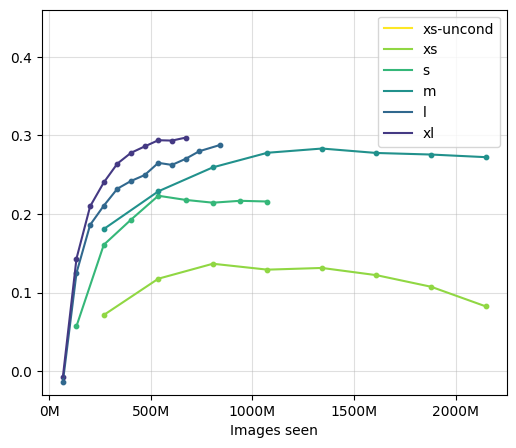

In [7]:
dataset = 'in64'  # 'in64', 'in512'
mode = 'overfit'  # 'train', 'val', 'train-val' or 'overfit'
metrics = ['FDD', 'FID']
models_data = {}  # Collect data for plotting

# 'many_models' to compare model sizes
# 'stop_many_models' to compare model sizes with early stopping
# 'stop_one_model' to compare different early_stop ids
plot_type = 'many_models' 

if plot_type == 'many_models':
    early_stops = [-1]
elif plot_type == 'stop_many_models':
    early_stops = [20, 18, 17]
elif plot_type == 'stop_one_model':
    early_stops = [16, 17, 18, 19, 20, -1]

# Get fd-metrics and their snaps
for early_stop in early_stops:
    if early_stop == -1:
        dataset_tmp = dataset
    else:
        dataset_tmp = f"{dataset}_stop{early_stop}"
        
    fd_data = get_fds(dataset_tmp, early_stop=early_stop)  # only for this model_size
    model_sizes = list(fd_data.keys())
    if dataset == 'in64':
        model_sizes = [s for s in model_sizes if 'xx' not in s]  # exclude xxs and xxl models on IN64, they don't exist

    if plot_type == 'many_models':
        model_sizes = ['xs-uncond', 'xs', 's', 'm', 'l', 'xl']
    elif plot_type == 'stop_many_models':
        # For figure with multiple model sizes
        if early_stop == 17:
            model_sizes = ['m', 'l', 'xl']
        elif early_stop == 18:
            model_sizes = ['xs', 's']
        elif early_stop == 20:
            model_sizes = ['xs-uncond']
    elif plot_type == 'stop_one_model':
        # For figure with multiple early_stop ids
        model_sizes = ['m']
    
    for model_name in model_sizes:
        print(f"Model: {model_name:9}, stopped at: {early_stop}")
        # assert False
        models_data[f"{model_name}-stop{early_stop}" if early_stop != -1 else model_name] = fd_data[model_name]

for metric in metrics:
    plt.figure(figsize=(6,5))
    overfit_vs_snaps(models_data, metric, mode=mode, x_axis='snaps', stop_in_label=plot_type=='one_model')
    if mode == 'overfit':
        plt.ylim([-0.03, 0.46])
    if mode == 'train-val' and metric == 'FDD':
        plt.ylim([40, 600])

    plt.legend()
    if save_figs:
        if plot_type == 'many_models':
            plt.savefig(f'{figs_folder}/figs/eccv2026/overfit_vs_snaps/overfit_vs_snaps-{mode}-{metric}-{dataset}.png', dpi=200, bbox_inches='tight')
        elif plot_type == 'stop_many_models':
            plt.savefig(f'{figs_folder}/figs/eccv2026/overfit_vs_snaps/overfit_vs_snaps-{mode}-{metric}-{dataset}-early_stop-models.png', dpi=200, bbox_inches='tight')
        elif plot_type == 'stop_one_models':
            plt.savefig(f'{figs_folder}/figs/eccv2026/overfit_vs_snaps/overfit_vs_snaps-{mode}-{metric}-{dataset}-early_stop.png', dpi=200, bbox_inches='tight')
    
    plt.show()
    plt.close()

### CIFAR-10/100

In [ ]:
datasets = ['cifar10', 'cifar100']  # 'in64', 'in512', 
mode = 'overfit'  # 'train', 'val', 'train-val' or 'overfit'

for metric in ['FDD', 'FID']:
    models_data = {}
    for d, dataset in enumerate(datasets):
        # Get fd-metrics and their snaps
        fd_data = get_fds(dataset, n_trainruns=15 if 'in' in dataset else 1)  # only for this model_size
        if metric == 'FDD':
            if mode != 'overfit':
                ylim = [150, 300]
            else:
                ylim = [-0.02, 0.05]
        if metric == 'FID':
            if mode != 'overfit':
                ylim = [3.5, 5.5]
            else:
                ylim = [-0.2, 0.6]  # Same as in64
        if dataset == 'in64':
            model_size = 'm'  # todo check what is good to compare here
            models_data[f"{dataset}-{model_size}"] = fd_data[model_size]
        elif dataset == 'in512': 
            model_size = 'm'  # todo check what is good to compare here
            models_data[f"{dataset}-{model_size}"] = fd_data[model_size]
        else:
            models_data[dataset] = fd_data
            
    overfit_vs_snaps(models_data, metric, mode=mode, x_axis='snaps')
    plt.ylim(ylim)
    plt.ylim([-0.03, 0.1])
    if save_figs:
        plt.savefig(f'{figs_folder}/figs/eccv2026/overfit_vs_snaps/overfit_vs_snaps-{mode}-{metric}-cifar.png', dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

## 2. Early stopping vs sigma

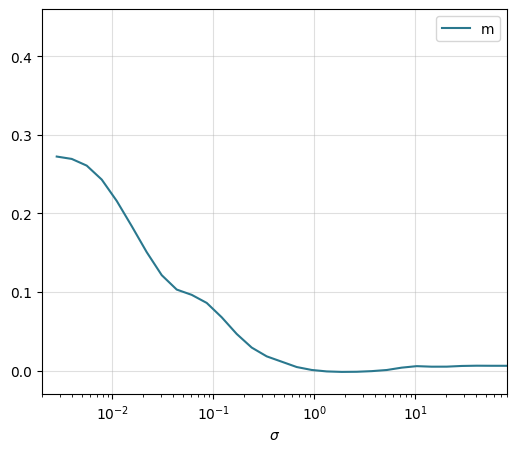

In [99]:
dataset = 'in64'
model_size = 'm'
plot_mode = 'overfit'  # 'overfit' or 'train-val'
f_extractor = 'incp'  # 'incp' or 'dino'
metric = 'FDD' if f_extractor == 'dino' else 'FID'


sigma_min, sigma_max = 2e-3, 80
num_steps = 32
start = float(torch.log(torch.tensor([sigma_min])) / torch.log(torch.tensor([10])))  # log(sigma_min) base 10
end = float(torch.log(torch.tensor([sigma_max])) / torch.log(torch.tensor([10])))  # log(sigma_max) base 10
t_steps = torch.logspace(start, end, num_steps)  # [num_steps]

# Load early_stop FDD results
fd_dict = {}
for mode in ['train', 'val']:
    data = pd.read_csv(f"{figs_folder}/data/fd_analysis/gen-v-{mode}/{dataset}_edm2{model_size}_stop.csv")
    all_stop_ids = data['early_stop'].to_numpy()
    all_fds = data[metric].to_numpy()
    ref_paths = data['ref_path1']
    fds, stop_ids = [], []
    for path in ref_paths.unique():
        mask = path == ref_paths
        fds.append(all_fds[mask].mean())
        assert np.all(all_stop_ids[mask] == all_stop_ids[mask][0])
        stop_ids.append(all_stop_ids[mask][0])
    fds = np.array(fds)
    stop_ids = np.array(stop_ids)
    sort_idx = np.argsort(stop_ids)
    fds = fds[sort_idx]
    fd_dict[mode] = fds

plt.figure(figsize=(6,5))
if plot_mode == 'overfit':
    gen_gap = (fd_dict['val'] - fd_dict['train'])/fd_dict['train']
    plt.plot(t_steps[-stop_ids[sort_idx]], gen_gap, c=plt.get_cmap('viridis')(2/5), label=model_size)
else:
    for mode in ['train', 'val']:
        plt.plot(t_steps[-stop_ids[sort_idx]], fd_dict[mode])
    
plot_layout(t_steps[0], t_steps[-1], scale_y=False, legend=True)
plt.ylim([-0.03, 0.46])
plt.xlabel("$\sigma$")
# train_data['snaps']

if save_figs:
    plt.savefig(f'{figs_folder}/figs/eccv2026/gen_gaps_vs_sigma/gap-{dataset}-edm2-{model_size}-stop-{f_extractor}.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()

## 3. Generalization gap for diffusion guidance

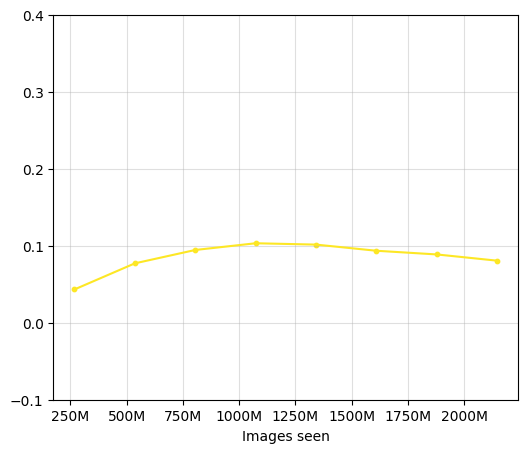

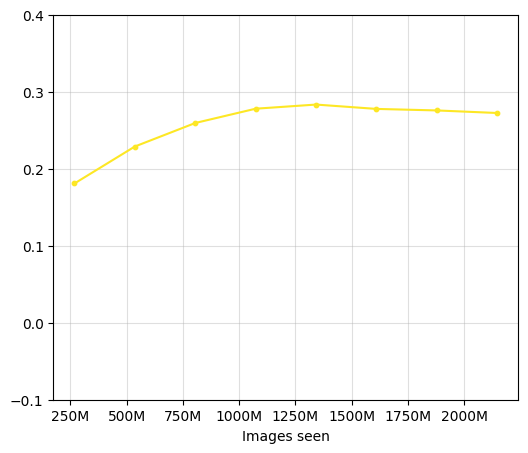

In [39]:
datasets = ['in64']  # 'in64', 'in512', 
mode = 'overfit'  # 'train', 'val', 'train-val' or 'overfit'

for metric in ['FDD', 'FID']:
    models_data = {}
    for dataset in datasets:
        # Get fd-metrics and their snaps
        fd_data = get_fds(dataset, n_trainruns=15 if 'in' in dataset else 1)  # only for this model_size
        if metric == 'FDD':
            if mode != 'overfit':
                ylim = [150, 300]
            else:
                ylim = [-0.02, 0.35]
        if metric == 'FID':
            if mode != 'overfit':
                ylim = [3.5, 5.5]
            else:
                ylim = [-0.2, 0.6]  # Same as in64
        if dataset == 'in64':
            model_size = 'm'  # todo check what is good to compare here
            models_data[f"{dataset}-{model_size}"] = fd_data[model_size]
        elif dataset == 'in512': 
            model_size = 'm'  # todo check what is good to compare here
            models_data[f"{dataset}-{model_size}"] = fd_data[model_size]
        else:
            models_data[dataset] = fd_data
    overfit_vs_snaps(models_data, metric, mode=mode, x_axis='snaps')
    plt.ylim(ylim)
    if save_figs:
        plt.savefig(f'{figs_folder}/figs/eccv2026/overfit_vs_snaps-{mode}-{metric}-cifar.png', dpi=200, bbox_inches='tight')
    plt.show()
    plt.close()

## Compare noise levels for different sigma schedules

In [ ]:
num_steps, rho = 64, 7
sigma_min, sigma_max = 2e-3, 80

start = float(torch.log(torch.tensor([sigma_min])) / torch.log(torch.tensor([10])))  # log(sigma_min) base 10
end = float(torch.log(torch.tensor([sigma_max])) / torch.log(torch.tensor([10])))  # log(sigma_max) base 10
t_steps = torch.logspace(start, end, num_steps)  # [num_steps]
t_steps[38]

In [ ]:
num_steps, rho = 32, 7
sigma_min, sigma_max = 2e-3, 80

step_indices = torch.arange(num_steps)
t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
t_steps = torch.cat([t_steps, torch.zeros_like(t_steps[:1])]) # t_N = 0
t_steps[18]